In [36]:
import json
from pathlib import Path
import pickle as pkl
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import analysis.ou_tuning.netpyne_res_parse_utils as parse_utils
import analysis.ou_tuning.data_proc_utils as proc_utils
from analysis.ou_tuning import xr_utils


dirpath_root = Path().resolve().parents[1]
exp_name_base = 'batch_rxbkg_state1_mech1'

exp_name = 'net_newsec_var_seed'
exp_name_sub = 'exp_a1_ee_fade_pulses_nseed_1_t_7.0_10.0_ictrl_wmult_0.25_ee_0.5_pulse_TC_d_150_T_500_c_25_w_0.1_r_100.0_544.0_t0_5000_jit_0'
job_label = '00000_seed_1000'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_name_base / exp_name
dirpath_res = dirpath_root / 'exp_results' / exp_name_base / exp_name / exp_name_sub

# Load sim results
fpath_pkl = dirpath_res / 'pkl' / f'data_{job_label}.pkl'
with open(fpath_pkl, 'rb') as fid:
    sim_res = pkl.load(fid)

# Load target rates
fpath_rates = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_rates)
target_rates = df.set_index('pop_name')['target_rate'].to_dict()


In [37]:
import importlib
import matplotlib

import matplotlib.pyplot as plt

importlib.reload(matplotlib)
importlib.reload(plt)

<module 'matplotlib.pyplot' from 'c:\\Users\\aleks\\.conda\\envs\\netpyne_batch\\lib\\site-packages\\matplotlib\\pyplot.py'>

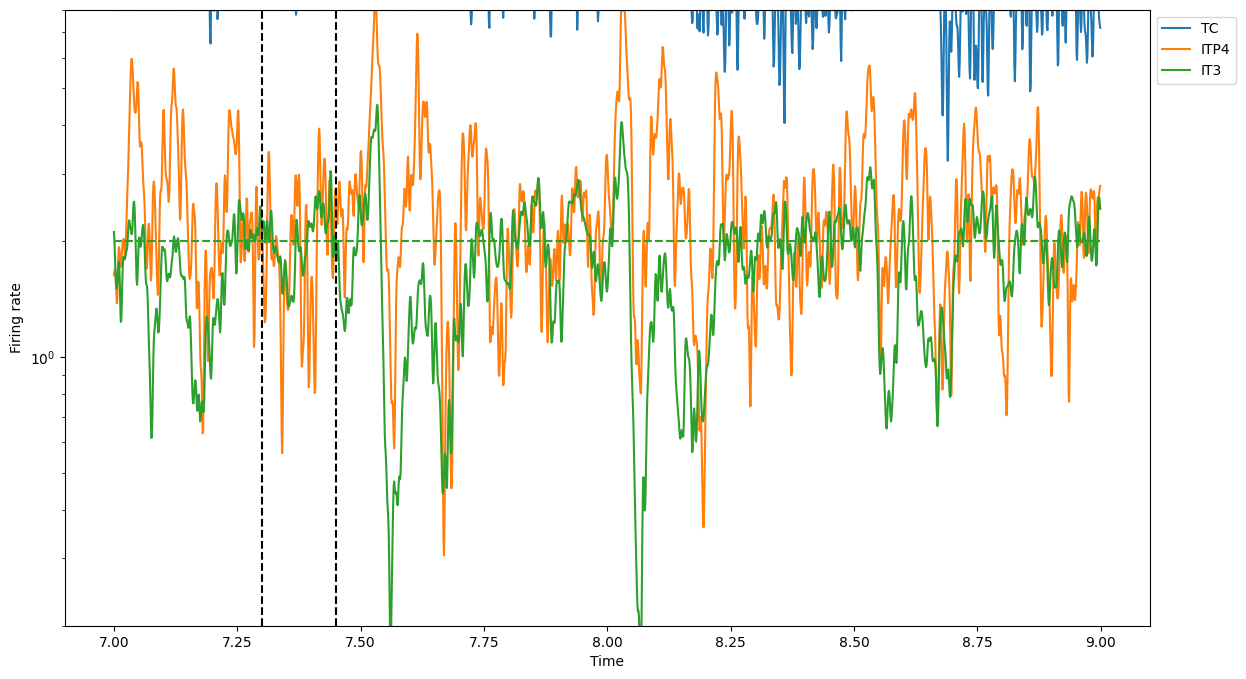

In [41]:
Tsim = parse_utils.get_sim_duration(sim_res)

dt_bin = 1e-3
tau = 2 * 1e-3

t0 = 7
T = 9

#pops_vis = sim_res['simConfig']['subnet_params']['pops_active']
#pops_vis = ['TC', 'ITP4', 'ITS4', 'IT2', 'IT3']
pops_vis = ['TC', 'ITP4', 'IT3']
#pops_vis = ['TC', 'ITP4', 'IT3', 'IT5A', 'IT6']

net_spikes = parse_utils.get_net_spikes(sim_res, pop_names=pops_vis)
ncells = parse_utils.get_net_size(sim_res)

r_data = proc_utils.calc_net_rate_dynamics(
    net_spikes, time_range=(t0, T), dt_bin=dt_bin,
    tau_smooth=tau, ncells=ncells)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(14, 8))
for n, pop in enumerate(pops_vis):
    tt, rr = r_data[pop]
    plt.plot(tt, rr, label=pop, color=colors[n])
    plt.plot([tt[0], tt[-1]], [target_rates[pop]] * 2, '--', color=colors[n])
plt.xlabel('Time')
plt.ylabel('Firing rate')
plt.axvline(7.3, color='k', linestyle='--')
plt.axvline(7.45, color='k', linestyle='--')
plt.legend(bbox_to_anchor=(1, 1))
plt.yscale('log')
#plt.ylim(0.05, None)
plt.ylim(0.2, 8)
plt.show()

#plt.savefig(dirpath_res / 'rvec_test.png', dpi=300, bbox_inches='tight')

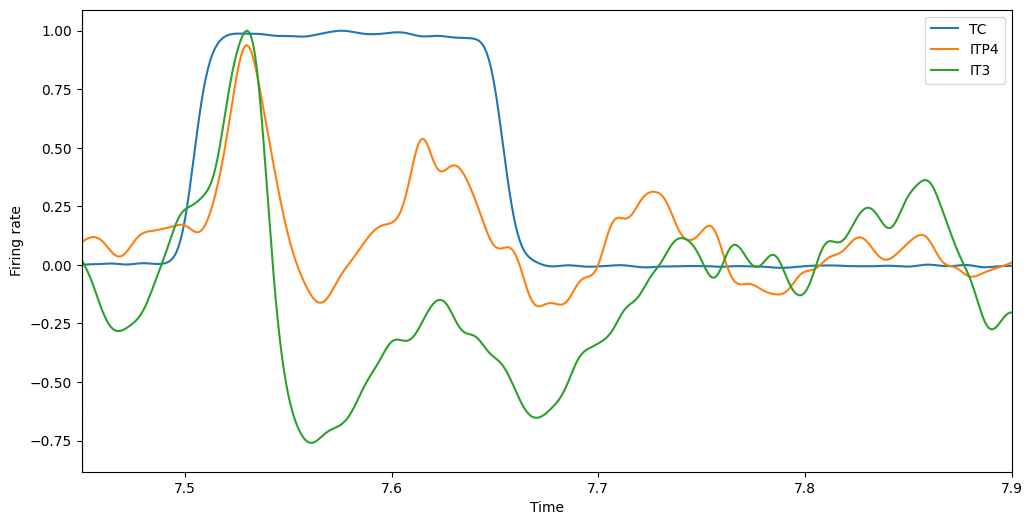

In [39]:
t_epoch = (7.45, 7.9)
t_bl = (7.3, 7.4)

plt.figure(figsize=(12, 6))
for n, pop in enumerate(pops_vis):
    tt, rr = r_data[pop]
    mask_bl = (tt >= t_bl[0]) & (tt <= t_bl[1])
    rr -= np.mean(rr[mask_bl])
    rr /= np.max(rr)
    plt.plot(tt, rr, label=pop, color=colors[n])
plt.xlabel('Time')
plt.ylabel('Firing rate')
plt.axvline(7.3, color='k', linestyle='--')
plt.axvline(7.45, color='k', linestyle='--')
plt.legend(bbox_to_anchor=(1, 1))
#plt.yscale('log')
#plt.ylim(0.05, None)
plt.xlim(t_epoch)
plt.show()